In [1]:
#Instalar librerias
!pip install dtreeviz
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 23.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<

In [ ]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV


#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import shap
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import export_graphviz
import graphviz
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)


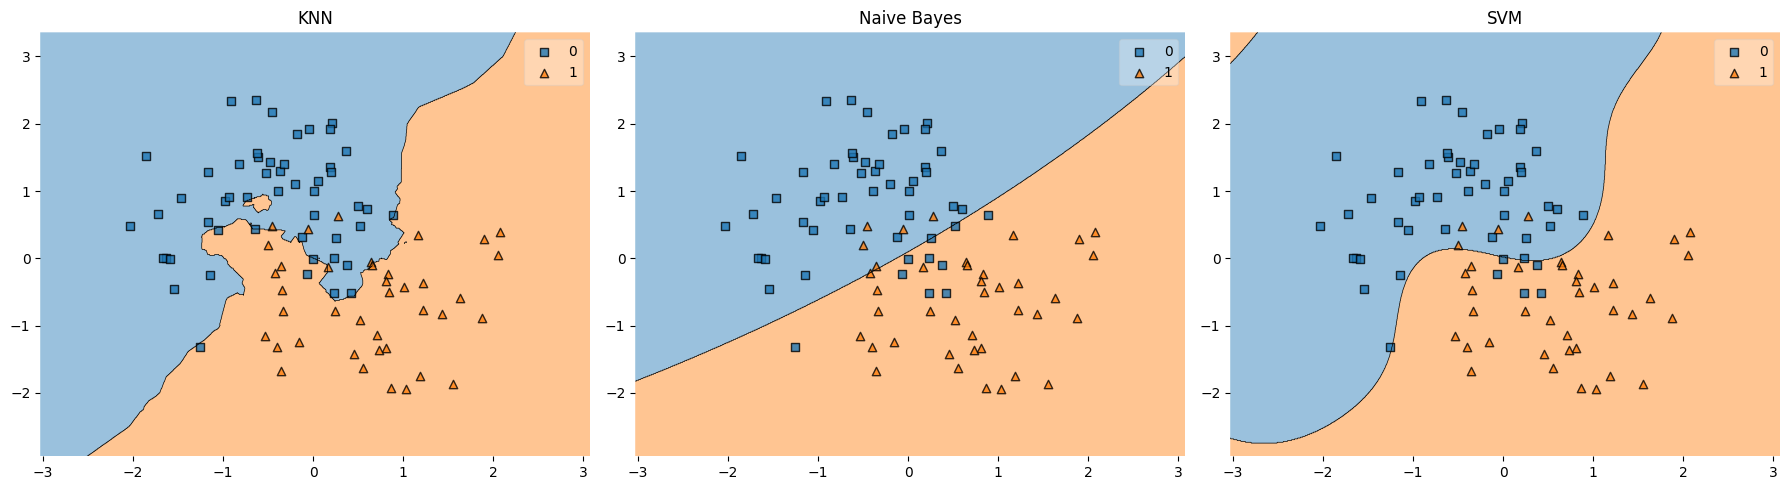

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from mlxtend.plotting import plot_decision_regions

# Datos 2D
X_vis, y_vis = make_moons(n_samples=300, noise=0.3, random_state=42)
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.3)

# Escalado
scaler = StandardScaler()
X_train_vis_scaled = scaler.fit_transform(X_train_vis)
X_test_vis_scaled = scaler.transform(X_test_vis)

# Entrenar modelos
knn_vis = KNeighborsClassifier().fit(X_train_vis_scaled, y_train_vis)
svm_vis = SVC().fit(X_train_vis_scaled, y_train_vis)
nb_vis = GaussianNB().fit(X_train_vis_scaled, y_train_vis)

# Graficar
plt.figure(figsize=(18, 5))
for i, (model, title) in enumerate(zip([knn_vis, nb_vis, svm_vis], ['KNN', 'Naive Bayes', 'SVM'])):
    plt.subplot(1, 3, i+1)
    plot_decision_regions(X_test_vis_scaled, y_test_vis, clf=model)
    plt.title(title)
plt.tight_layout()
plt.show()


In [ ]:
# Descargar los datos con pandas
df_red = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',sep=';')

df_white = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv',sep=';')

df = pd.concat([df_red, df_white])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
#No queremos incluir la variable quality dentro del tratamiento de outliers
df_outliers = df.drop(columns='quality')
df_target= df['quality']



Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df_outliers.columns:
    col_outliers = ((df_outliers[col] < (Q1[col] - 3 * IQR[col])) | (df_outliers[col] > (Q3[col] + 3 * IQR[col]))) # se detectan outliers usando el rango interquartil
    df_outliers.loc[col_outliers, col] = df_outliers[col].median() #Los reemplzamos con la mediana

df_target_b= df['quality'].apply(lambda x: 1 if x >= 7 else 0)

#Juntamos el dataset limpio con el nuevo target
df_limpio = df_outliers.copy()
df_limpio['quality'] = df_target_b
df_limpio.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [ ]:
# División de datos en entrenamiento y test
X = df_limpio.drop(['quality'], axis=1)
y = df_limpio['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Usaremos division 80-20 por la cantidad de datos, lo usual en datasets más grandes es 70-30

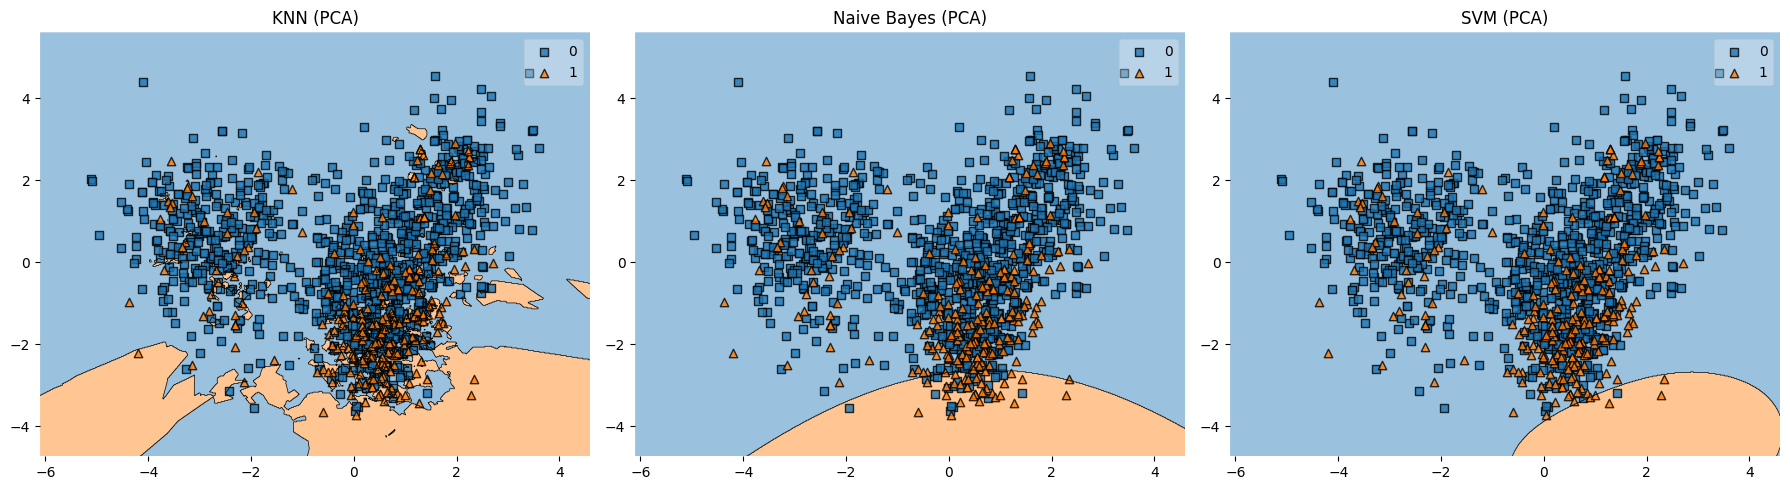

In [ ]:
# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reducir a 2D para visualización
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entrenar modelos sobre datos proyectados
knn_pca = KNeighborsClassifier().fit(X_train_pca, y_train)
svm_pca = SVC().fit(X_train_pca, y_train)
nb_pca = GaussianNB().fit(X_train_pca, y_train)

# Asegurar que y_test sea array NumPy
y_test_array = np.array(y_test)

# Graficar fronteras de decisión
plt.figure(figsize=(18, 5))
for i, (model, title) in enumerate(zip([knn_pca, nb_pca, svm_pca], ['KNN (PCA)', 'Naive Bayes (PCA)', 'SVM (PCA)'])):
    plt.subplot(1, 3, i+1)
    plot_decision_regions(X_test_pca, y_test_array, clf=model)
    plt.title(title)
plt.tight_layout()
plt.show()


In [ ]:
# Entrenar modelos sobre datos proyectados
knn = KNeighborsClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)


Evaluación del modelo: KNN


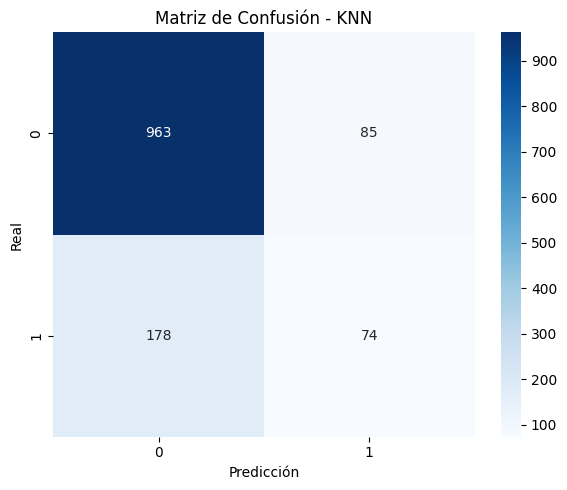

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1048
           1       0.47      0.29      0.36       252

    accuracy                           0.80      1300
   macro avg       0.65      0.61      0.62      1300
weighted avg       0.77      0.80      0.78      1300




Evaluación del modelo: Naive Bayes


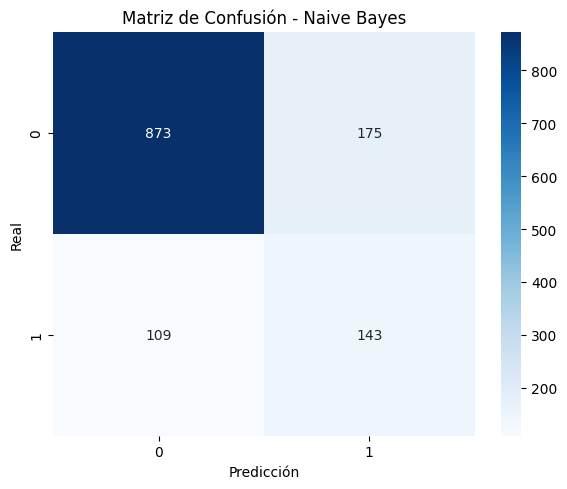

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1048
           1       0.45      0.57      0.50       252

    accuracy                           0.78      1300
   macro avg       0.67      0.70      0.68      1300
weighted avg       0.80      0.78      0.79      1300




Evaluación del modelo: SVM


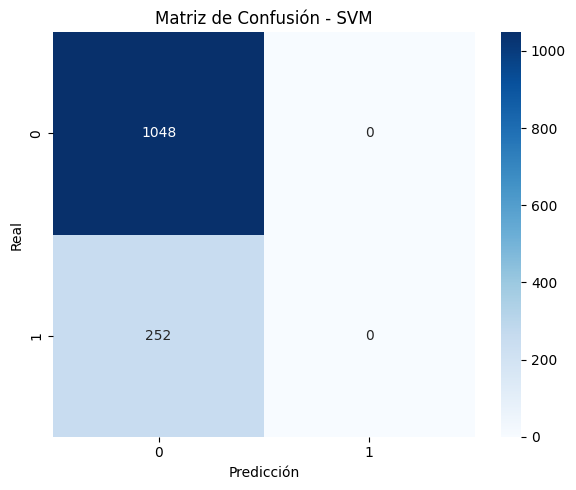

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1048
           1       0.00      0.00      0.00       252

    accuracy                           0.81      1300
   macro avg       0.40      0.50      0.45      1300
weighted avg       0.65      0.81      0.72      1300

El modelo SVM no tiene método predict_proba. ROC no disponible.


In [ ]:
# Lista de modelos y nombres
modelos = [knn, nb, svm]
nombres = ['KNN', 'Naive Bayes', 'SVM']

# Evaluación por modelo
for model, name in zip(modelos, nombres):
    print(f"\nEvaluación del modelo: {name}")

    # Predicciones
    y_pred = model.predict(X_test)

    # Matriz de Confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.tight_layout()
    plt.show()

    # Reporte de Clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Curva ROC
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        auc_score = roc_auc_score(y_test, y_probs)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
        fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
        fig.update_layout(title=f'Curva ROC - {name} (AUC: {auc_score:.3f})',
                          xaxis_title='Tasa de Falsos Positivos (FPR)',
                          yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                          width=700, height=500)
        fig.show()
    else:
        print(f"El modelo {name} no tiene método predict_proba. ROC no disponible.")

Aplicación en test de seasonal vaccine

In [ ]:
# obtener desde GitHub
url_flu_codificado = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_filtrado_codificado.csv"
url_flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_test_final_codificado.csv"

# Carga los datos
flu_codificado = pd.read_csv(url_flu_codificado)
print(flu_codificado.head())

flu_test = pd.read_csv(url_flu_test)
print(flu_test.head())

   opinion_seas_vacc_effective  opinion_seas_risk  doctor_recc_seasonal  \
0                          2.0                1.0                   0.0   
1                          4.0                2.0                   0.0   
2                          4.0                1.0                   0.0   
3                          5.0                4.0                   1.0   
4                          3.0                1.0                   0.0   

   age_group  opinion_h1n1_risk  opinion_h1n1_vacc_effective  \
0          3                1.0                          3.0   
1          1                4.0                          5.0   
2          0                1.0                          3.0   
3          4                3.0                          3.0   
4          2                3.0                          3.0   

   employment_industry  doctor_recc_h1n1  employment_occupation  \
0                   11               0.0                     11   
1                   13        

In [ ]:
# Cargar dataset limpio
X = flu_codificado.drop(columns='seasonal_vaccine')
y = flu_codificado['seasonal_vaccine']

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)
# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


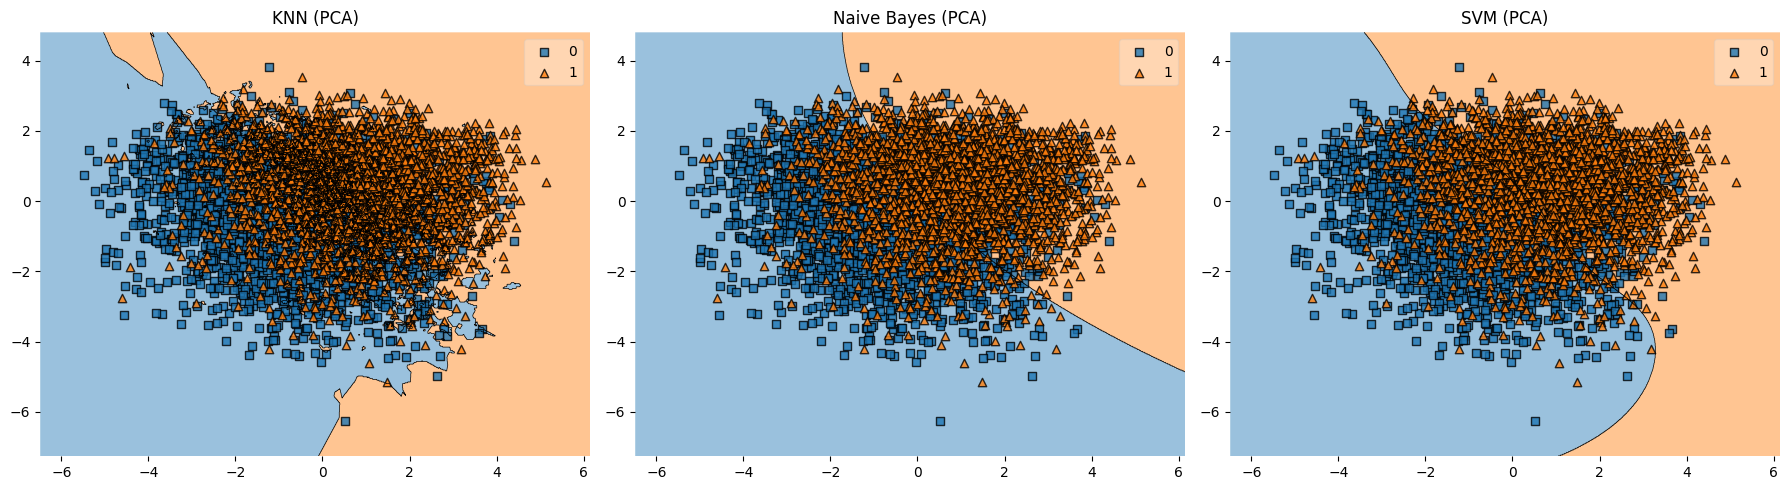

In [ ]:
# Reducir a 2D para visualización (tarda aprox 10 minutos)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Entrenar modelos sobre datos proyectados
knn_pca = KNeighborsClassifier().fit(X_train_pca, y_train)
svm_pca = SVC().fit(X_train_pca, y_train)
nb_pca = GaussianNB().fit(X_train_pca, y_train)

# Asegurar que y_test sea array NumPy
y_test_array = np.array(y_test)

# Graficar fronteras de decisión
plt.figure(figsize=(18, 5))
for i, (model, title) in enumerate(zip([knn_pca, nb_pca, svm_pca], ['KNN (PCA)', 'Naive Bayes (PCA)', 'SVM (PCA)'])):
    plt.subplot(1, 3, i+1)
    plot_decision_regions(X_test_pca, y_test_array, clf=model)
    plt.title(title)
plt.tight_layout()
plt.show()

In [ ]:
# Entrenar modelos sobre datos proyectados
knn = KNeighborsClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)


Evaluación del modelo: KNN


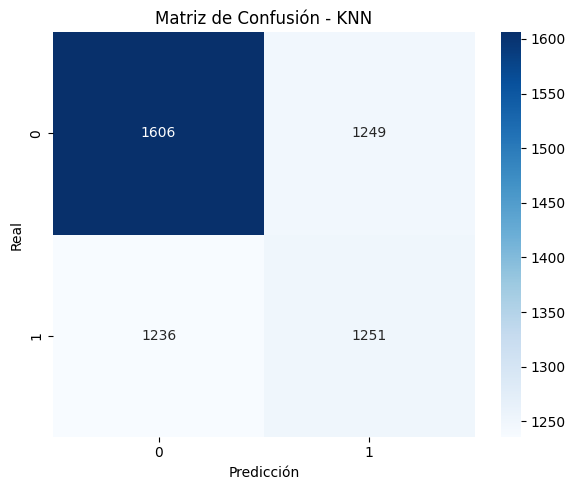

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.57      0.56      0.56      2855
           1       0.50      0.50      0.50      2487

    accuracy                           0.53      5342
   macro avg       0.53      0.53      0.53      5342
weighted avg       0.53      0.53      0.53      5342




Evaluación del modelo: Naive Bayes


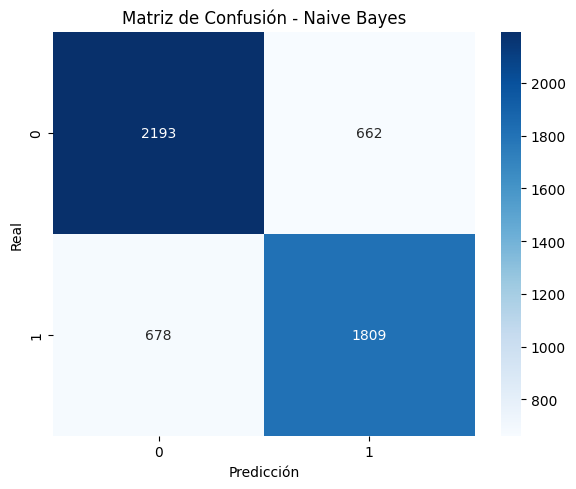

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77      2855
           1       0.73      0.73      0.73      2487

    accuracy                           0.75      5342
   macro avg       0.75      0.75      0.75      5342
weighted avg       0.75      0.75      0.75      5342




Evaluación del modelo: SVM


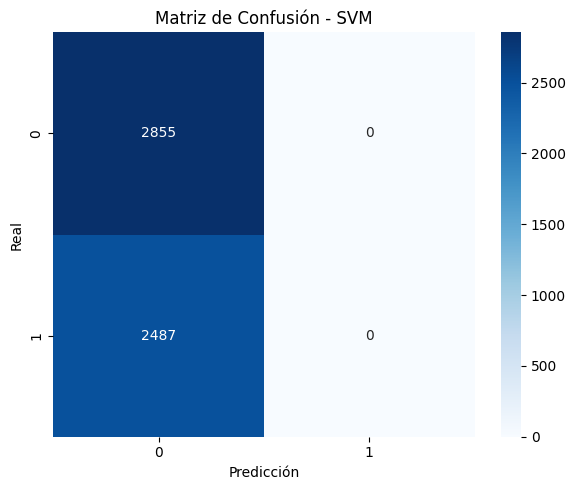

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.53      1.00      0.70      2855
           1       0.00      0.00      0.00      2487

    accuracy                           0.53      5342
   macro avg       0.27      0.50      0.35      5342
weighted avg       0.29      0.53      0.37      5342

El modelo SVM no tiene método predict_proba. ROC no disponible.


In [ ]:
# Lista de modelos y nombres
modelos = [knn, nb, svm]
nombres = ['KNN', 'Naive Bayes', 'SVM']

# Evaluación por modelo
for model, name in zip(modelos, nombres):
    print(f"\nEvaluación del modelo: {name}")

    # Predicciones
    y_pred = model.predict(X_test)

    # Matriz de Confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.tight_layout()
    plt.show()

    # Reporte de Clasificación
    print("Reporte de Clasificación:")
    print(classification_report(y_test, y_pred))

    # Curva ROC
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        auc_score = roc_auc_score(y_test, y_probs)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
        fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
        fig.update_layout(title=f'Curva ROC - {name} (AUC: {auc_score:.3f})',
                          xaxis_title='Tasa de Falsos Positivos (FPR)',
                          yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                          width=700, height=500)
        fig.show()
    else:
        print(f"El modelo {name} no tiene método predict_proba. ROC no disponible.")

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

svm = SVC(class_weight='balanced')
calibrated = CalibratedClassifierCV(svm, cv=5)
calibrated.fit(X_train, y_train)
y_pred = calibrated.predict(X_test)


In [ ]:

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

[[2855    0]
 [2487    0]]
              precision    recall  f1-score   support

           0      0.534     1.000     0.697      2855
           1      0.000     0.000     0.000      2487

    accuracy                          0.534      5342
   macro avg      0.267     0.500     0.348      5342
weighted avg      0.286     0.534     0.372      5342



In [ ]:
from sklearn.model_selection import GridSearchCV #10min
from sklearn.svm import SVC

# Parámetros reducidos para acelerar
param_grid = {
    'C': [1, 10],              # valores representativos
    'gamma': ['scale', 0.1],   # gamma bajo y automático
    'kernel': ['rbf']          # solo RBF
}

# SVM con balanceo de clases
svm = SVC(class_weight='balanced')

# GridSearch con paralelización
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=3,              # menos folds para acelerar
    n_jobs=-1,         # usa todos los núcleos disponibles
    verbose=1
)

# Entrenamiento
grid.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid.best_params_)
print("Mejor score:", grid.best_score_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Entrena el mejor modelo encontrado por GridSearch
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train)

# Predicciones
y_pred = best_svm.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

# Reporte de clasificación
report = classification_report(y_test, y_pred, digits=3)
print("Classification Report:")
print(report)

# Visualización de la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Real 0', 'Real 1'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Mejor SVM")
plt.tight_layout()
plt.show()
